A notebook for looking at Allen quality metrics and testing how to use them for labelling clusters

In [10]:
import os
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

In [36]:
Path = r"D:\JAL6_18mar"

qc = pd.read_csv(os.path.join(Path, "quality_metrics.csv"))
cluster_groups = pd.read_csv(os.path.join(Path, "cluster_group.tsv"), sep='\t')
print(len(cluster_groups), len(qc))
mua_id = cluster_groups[cluster_groups['KSLabel'] == 'mua']['cluster_id'].to_numpy()
good_id = cluster_groups[cluster_groups['KSLabel'] == 'good']['cluster_id'].to_numpy()
print(f"mua: {len(mua_id)}, good: {len(good_id)}")
qc_id = qc['Unnamed: 0']
qc_good = qc_id.isin(good_id).to_numpy()
qc_mua = qc_id.isin(mua_id).to_numpy()

586 580
mua: 312, good: 274


In [9]:
plt.rcParams.update({'font.size': 14})

def plot_metric(data, bins, x_axis_label, color, max_value=-1):
    
    h, b = np.histogram(data, bins=bins, density=True)

    x = b[:-1]
    y = gaussian_filter1d(h, 1)

    plt.plot(x, y, color=color)
    plt.xlabel(x_axis_label)
    plt.gca().get_yaxis().set_visible(False)
    [plt.gca().spines[loc].set_visible(False) for loc in ['right', 'top', 'left']]
    if max_value < np.max(y) * 1.1:
        max_value = np.max(y) * 1.1
    plt.ylim([0, max_value])
    
    return max_value

In [16]:
qc.columns

Index(['Unnamed: 0', 'amplitude_cutoff', 'amplitude_cv', 'amplitude_median',
       'firing_range', 'firing_rate', 'isi_violations_ratio',
       'isi_violations_count', 'num_spikes', 'presence_ratio',
       'rp_contamination', 'rp_violations', 'sd_ratio', 'sliding_rp_violation',
       'snr', 'sync_spike_2', 'sync_spike_4', 'sync_spike_8'],
      dtype='object')

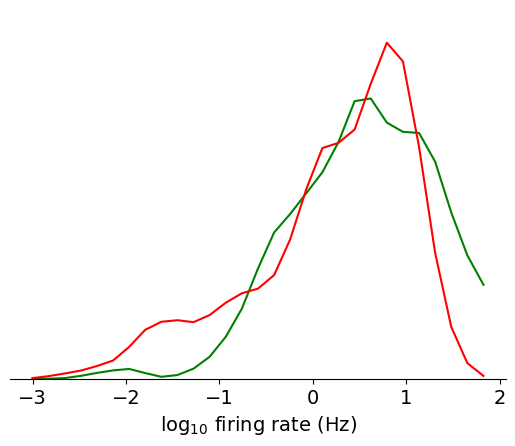

In [40]:
"""Firing rate"""
data = np.log10(qc['firing_rate'].to_numpy())
bins = np.linspace(-3,2,30)

max_value = plot_metric(data[qc_good], bins, 'log$_{10}$ firing rate (Hz)', 'green')
max_value = plot_metric(data[qc_mua], bins, 'log$_{10}$ firing rate (Hz)', 'red')

% good above threshold: 0.9671532846715328, % mua above threshold: 0.9150326797385621


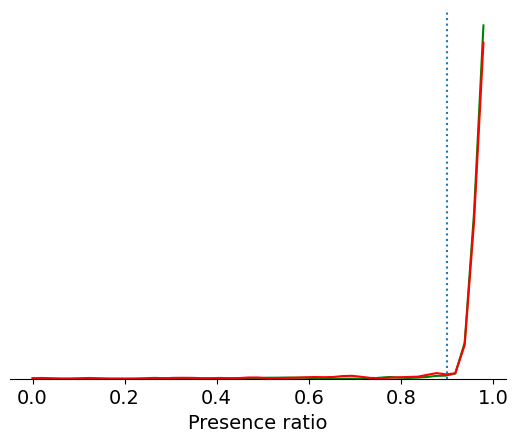

In [ ]:
"""Presence ratio """
bins = np.linspace(0,1,50)
data = qc['presence_ratio'].to_numpy()

max_value = plot_metric(data[qc_good], bins, 'Presence ratio', 'green')
max_value = plot_metric(data[qc_mua], bins, 'Presence ratio', 'red')

plt.plot([0.9, 0.9],[0,max_value], ':')

good_pr_threshold = np.sum(data[qc_good] > 0.9) / len(data[qc_good])
mua_pr_threshold = np.sum(data[qc_mua] > 0.9) / len(data[qc_mua])
print(f"% good above threshold: {good_pr_threshold}, % mua above threshold: {mua_pr_threshold}")

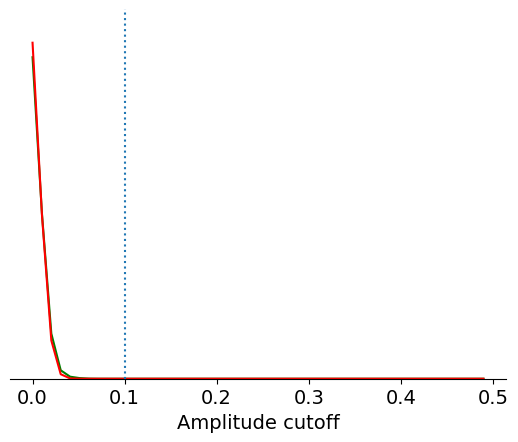

In [ ]:
"""Amplitude cutoff"""
bins = np.linspace(0,0.5,50)
data = qc['amplitude_cutoff'].to_numpy()
max_value = -np.inf
    
max_value = plot_metric(data[qc_good], bins, 'Amplitude cutoff', 'green')
max_value = plot_metric(data[qc_mua], bins, 'Amplitude cutoff', 'red')
    
plt.plot([0.1, 0.1],[0,max_value], ':')

% good with no violations: 0.12408759124087591, % mua with no violations: 0.13071895424836602


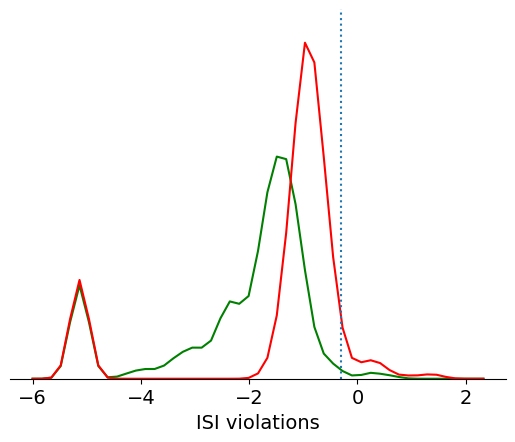

In [ ]:
"""ISI violations ratio?"""
bins = np.linspace(-6, 2.5,50)
data = np.log10(qc['isi_violations_ratio'].to_numpy() + 1e-5)
    
max_value = plot_metric(data[qc_good], bins, 'ISI violations', 'green')
max_value = plot_metric(data[qc_mua], bins, 'ISI violations', 'red')
    
plt.plot([np.log10(0.5), np.log10(0.5)],[0,max_value], ':')
# at -5 are the units with no violations!

no_violation_good = np.sum(qc['isi_violations_ratio'][qc_good] == 0) / len(qc[qc_good])
no_violation_mua = np.sum(qc['isi_violations_ratio'][qc_mua] == 0) / len(qc[qc_mua])
print(f"% good with no violations: {no_violation_good}, % mua with no violations: {no_violation_mua}")